# Tracking videos: Quads design (3dp pla + blue shims) for static cloaking of a smile-shaped void - Cloaked design


## Imports

In [1]:
import matplotlib.pyplot as plt
from typing import Union
from mechanicalmetamaterialcloaks.plotting import generate_animation
from mechanicalmetamaterialcloaks.utils import save_data, load_data, SolutionData
from problems.quads_static_cloaking import OptimizationProblem
import cv2

from pathlib import Path
import pandas as pd
from scripts.tracking.tracking_gray_xcorr import mark_reference_frame
from scripts.tracking.tracking_gray_xcorr import tracking_better as tracking
from scripts.tracking.utils import smooth_fields_SG
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)  # enable float64 type

plt.style.use(["science", "grid"])
%matplotlib widget


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


## Paths

In [ ]:
# Where to load/save data
data_folder = Path("../../../data/quads_static_cloaking_3dp_pla_shims")
# Where to save plots and animations
out_folder = Path("../../../out/quads_static_cloaking_3dp_pla_shims")

## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [ ]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()
geometry = problem.cloaked_geometry


Setup solver of the intact geometry
Compute dynamics of the intact geometry
Setup solver of the voided geometry
Initialization done


## Videos to process


In [4]:
# Subfolder for videos and tracking data
design_name = optimization_filename

# Experimental videos to be processed
video_paths = sorted(list(Path(f"{data_folder}/{design_name}/videos").glob("cloaked_*.mp4")))

## Tracking: Voided design


### Tracking helper functions



In [26]:
# Select the voided design i.e. the optimized design
design_values = optimization.design_values[-1]

# Define the tracked geometry i.e the reference geometry without clamped blocks
reference_centroids = geometry.block_centroids(
    *problem.cloak_to_all_shifts(design_values)
)[problem.moving_blocks_ids_cg]
reference_shapes = geometry.centroid_node_vectors(
    *problem.cloak_to_all_shifts(design_values)
)[problem.moving_blocks_ids_cg]


def morphological_transformation(thresh):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    transformed = cv2.morphologyEx(
        thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    transformed = cv2.morphologyEx(
        transformed, cv2.MORPH_CLOSE, kernel, iterations=1)
    return transformed


def add_clamped_blocks_data(tracked_data: SolutionData) -> SolutionData:
    """Add the data for the clamped blocks to the tracked data (for easier comparison with simulations)."""
    block_centroids = problem.geometry.block_centroids(
        *problem.cloak_to_all_shifts(design_values))
    centroid_node_vectors = problem.geometry.centroid_node_vectors(
        *problem.cloak_to_all_shifts(design_values))
    fields = jnp.zeros((len(tracked_data.timepoints), 2, len(block_centroids), 3))

    block_centroids = block_centroids.at[problem.moving_blocks_ids].set(
        tracked_data.block_centroids)
    centroid_node_vectors = centroid_node_vectors.at[problem.moving_blocks_ids].set(
        tracked_data.centroid_node_vectors
    )
    fields = fields.at[:, :, problem.moving_blocks_ids].set(
        tracked_data.fields)

    return SolutionData(
        block_centroids=block_centroids,
        centroid_node_vectors=centroid_node_vectors,
        bond_connectivity=problem.geometry.bond_connectivity(),
        timepoints=tracked_data.timepoints,
        fields=fields,
    )


# Marker placement parameters
marker_placement_params = dict(
    calib_xy=(15*14/566, 15*14/566),
    ROI_X=(155+10, 950-55+10),
    ROI_Y=(580+10, 1320-40),
    blur_size=1,
    threshold=60,
    adaptive_thresholding=True,
    adaptive_thresholding_block=1001,
    morphological_transformation=morphological_transformation,
    block_area=(70, 3500),
    reference_centroids=reference_centroids,
    reference_shapes=reference_shapes,
    aspect_ratio_threshold=0.05,
    # Place markers a little bit closer to the centroid to have better features for cross-correlation.
    markers_scaled_position=0.9,
)
# Cross-correlation parameters
xcorr_params = dict(
    marker_template_size=15,  # px
    search_window_size=19,  # px
    upscaling_factor=10,
    template_update_rate=1,
)


def show_reference_frame(video_path: Union[str, Path], frame: int = 0):
    mark_reference_frame(
        video_path=str(video_path),
        **marker_placement_params,
        frame=frame,
        show=True,
    )


def track_video(video_path: Union[str, Path], plot_centroids: bool = False, show_tracked_frame: bool = False):
    tracked_data = tracking(
        video_path=str(video_path),
        start_end_video=(120, 12120),
        framerate=120,
        step_size=90,
        **marker_placement_params,
        **xcorr_params,
        show_tracked_frame=show_tracked_frame,
    )
    # Add the data for the clamped blocks
    # tracked_data = add_clamped_blocks_data(tracked_data)
    # Shift timepoints to start at 0
    tracked_data = tracked_data._replace(
        timepoints=tracked_data.timepoints - tracked_data.timepoints[0])
    # Smooth the data with a Savitzky-Golay filter
    # tracked_data._replace(fields=smooth_fields_SG(tracked_data.fields, window_length=11, polyorder=3))

    if plot_centroids:
        # Plot centroids
        plt.figure(figsize=(8, 8*(geometry.n2_blocks+1) /
                   geometry.n1_blocks), constrained_layout=True)
        plt.title(r"Centroids - frame \#0")
        plt.scatter(*reference_centroids.T, label="Reference")
        plt.scatter(
            *tracked_data.block_centroids.T, label="Tracked")
        for i, pt in enumerate(tracked_data.block_centroids):
            plt.text(*pt, f"{i}")
        plt.axis("equal")
        plt.legend(bbox_to_anchor=(0.5, -0.08), loc='center', ncol=3)

    return tracked_data

### Process one video


#### Place markers

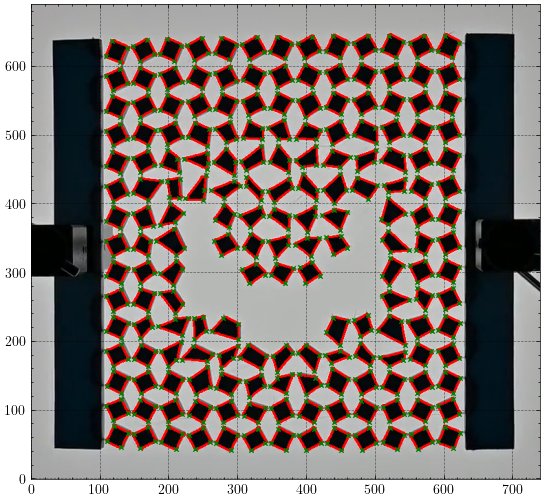

In [21]:
plt.close("all")
show_reference_frame(video_paths[0], frame=120)

#### Run tracking and save the tracking data

In [ ]:
# # Track each video and save the tracked data
# for path in video_paths:
#     tracked_data = track_video(path, show_tracked_frame=True)
#     save_data(f"{data_folder}/{design_name}/dynamic-data/tracking_exp/{path.stem}.pkl", tracked_data._asdict())


Data saved at ../../../data/quads_static_cloaking_3dp_pla_shims/opt_integrated_with_angle_30_and_length_3_constraints_quads_15x15_amplitude_15.0_initial_angle_20.0_void_big_smile/dynamic-data/tracking_exp/cloaked_compressed.pkl


## Load tracking data


In [28]:
# Find all data files in the dynamic-data folder
tracked_data_paths = sorted(list(Path(
    f"{data_folder}/{design_name}/dynamic-data/tracking_exp/").glob("*.pkl")), key=lambda p: p.stem[-2:])

# Load the tracked data as a dataframe
tracked_data = pd.DataFrame({
    "label": [p.stem for p in tracked_data_paths],
    "data": [SolutionData(**load_data(p)) for p in tracked_data_paths],
})

# Smooth tracking data
tracked_data.data = tracked_data.apply(
    lambda row: row.data._replace(fields=smooth_fields_SG(
        row.data.fields, window_length=[[10, 10, 25], [10, 10, 25]], polyorder=2)),
    axis=1,
)
tracked_data


,label,data
0,holed_compressed,"([[15.0, 0.0], [29.553516937016227, -0.2486934..."
1,cloaked_compressed,"([[15.0, 0.0], [29.471952471679693, -0.4812618..."
